# Detector de Deepfakes con YOLO: Cuaderno Final Limpio

Este cuaderno conserva el comportamiento que mejor te funcionó en `notebooks/02-training-yolo.ipynb`, pero con una estructura más limpia y una demo de inferencia más presentable.

Objetivos:
- entrenar con la misma lógica efectiva del cuaderno 02
- usar por defecto el modelo de referencia ya entrenado mientras no lances otra corrida
- mostrar ejemplos rápidos con imágenes `fake` y `real`
- ofrecer una celda final para probar cualquier URL o imagen local

## 1. Preparación del entorno

Carga rutas del proyecto, utilidades compartidas y dependencias para entrenamiento e inferencia.

In [1]:
from __future__ import annotations

import random
import sys
from pathlib import Path
from urllib.parse import urlparse

import matplotlib.pyplot as plt
import requests
from PIL import Image


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'src').exists() and (candidate / 'scripts').exists():
            return candidate
    raise FileNotFoundError('No se encontró la raíz del proyecto.')


PROJECT_ROOT = find_project_root()
SRC = PROJECT_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from detector_deepfake.config import ensure_yolo_dataset_layout, get_runs_dir
from detector_deepfake.inference import classify_image, resolve_model_path
from ultralytics import YOLO

plt.style.use('seaborn-v0_8-darkgrid')
print(f'Proyecto cargado: {PROJECT_ROOT}')

Proyecto cargado: D:\proyectos\Detector de ia


## 2. Configuración compatible con el cuaderno 02

Los valores de esta celda están alineados con la receta que dio mejores resultados en las corridas previas con YOLO.

Puntos clave:
- `BATCH = 64`
- `FRACTION = 1.0`
- `BALANCE_DATASET = False`
- `WORKERS = 0` en Windows
- modelo de referencia por defecto: `deepfake_det_50606/weights/best.pt`

Para evitar entrenar por accidente, `CONFIRM_TRAINING` arranca en `False`.

In [2]:
RAW_PROJECT_DATASET_DIR = PROJECT_ROOT / 'dataset_deepdetect' / 'ddata'
PROJECT_DATASET_DIR = RAW_PROJECT_DATASET_DIR.resolve()
DATASET_DIR = ensure_yolo_dataset_layout(PROJECT_DATASET_DIR)
RUNS_DIR = get_runs_dir()
DOWNLOAD_DIR = PROJECT_ROOT / 'results' / 'generated' / 'downloads'
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

REFERENCE_MODEL = RUNS_DIR / 'deepfake_det_50606' / 'weights' / 'best.pt'
BASE_MODEL = 'yolov8n-cls.pt'
EXPERIMENT_NAME = 'legacy_clean_retrain'

EPOCHS = 5
BATCH = 64
IMGSZ = 224
WORKERS = 0
DEVICE = '0'
FRACTION = 1.0
SAVE_PERIOD = -1
CACHE_IMAGES = False

CONFIRM_TRAINING = False
BALANCE_DATASET = False
USE_LATEST_MODEL = False
MODEL_PATH = REFERENCE_MODEL if REFERENCE_MODEL.exists() else None

if not DATASET_DIR.exists():
    raise FileNotFoundError(f'No existe el dataset: {DATASET_DIR}')

print('Configuración activa:')
print(f'  DATASET_DIR        = {DATASET_DIR}')
print(f'  RUNS_DIR           = {RUNS_DIR}')
print(f'  REFERENCE_MODEL    = {REFERENCE_MODEL}')
print(f'  BASE_MODEL         = {BASE_MODEL}')
print(f'  EXPERIMENT_NAME    = {EXPERIMENT_NAME}')
print(f'  EPOCHS             = {EPOCHS}')
print(f'  BATCH              = {BATCH}')
print(f'  IMGSZ              = {IMGSZ}')
print(f'  WORKERS            = {WORKERS}')
print(f'  DEVICE             = {DEVICE}')
print(f'  FRACTION           = {FRACTION}')
print(f'  SAVE_PERIOD        = {SAVE_PERIOD}')
print(f'  CONFIRM_TRAINING   = {CONFIRM_TRAINING}')
print(f'  BALANCE_DATASET    = {BALANCE_DATASET}')
print(f'  USE_LATEST_MODEL   = {USE_LATEST_MODEL}')

if RAW_PROJECT_DATASET_DIR.resolve() != RAW_PROJECT_DATASET_DIR:
    print('\nAviso: la carpeta dataset_deepdetect redirige a una ruta real externa.')
    print(f'  Ruta visible = {RAW_PROJECT_DATASET_DIR}')
    print(f'  Ruta real    = {PROJECT_DATASET_DIR}')

Configuración activa:
  DATASET_DIR        = C:\Users\marce\.cache\kagglehub\datasets\ayushmandatta1\deepdetect-2025\versions\1\ddata
  RUNS_DIR           = D:\proyectos\Detector de ia\runs\classify\runs_yolo
  REFERENCE_MODEL    = D:\proyectos\Detector de ia\runs\classify\runs_yolo\deepfake_det_50606\weights\best.pt
  BASE_MODEL         = yolov8n-cls.pt
  EXPERIMENT_NAME    = legacy_clean_retrain
  EPOCHS             = 5
  BATCH              = 64
  IMGSZ              = 224
  WORKERS            = 0
  DEVICE             = 0
  FRACTION           = 1.0
  SAVE_PERIOD        = -1
  CONFIRM_TRAINING   = False
  BALANCE_DATASET    = False
  USE_LATEST_MODEL   = False

Aviso: la carpeta dataset_deepdetect redirige a una ruta real externa.
  Ruta visible = D:\proyectos\Detector de ia\dataset_deepdetect\ddata
  Ruta real    = C:\Users\marce\.cache\kagglehub\datasets\ayushmandatta1\deepdetect-2025\versions\1\ddata


## 3. Validación del dataset

Esta celda resume cuántas imágenes hay por split y por clase para confirmar que YOLO verá la estructura esperada.

Split        fake     real    Total
--------------------------------------
train      41,592   41,592   83,184
val        10,399   11,377   21,776
test       10,399   11,377   21,776


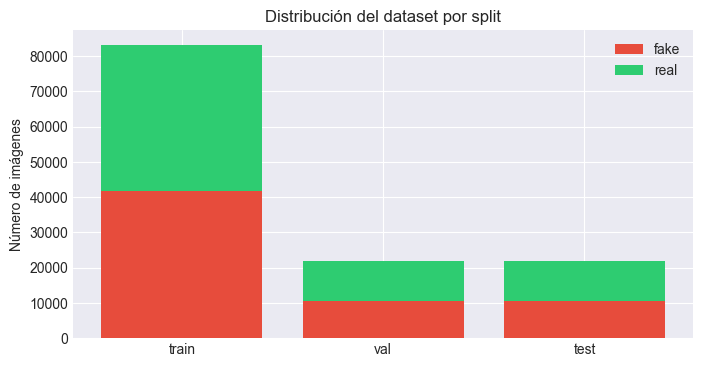

In [8]:
def count_images(split_dir: Path) -> dict[str, int]:
    counts: dict[str, int] = {}
    for class_dir in sorted(path for path in split_dir.iterdir() if path.is_dir()):
        counts[class_dir.name] = sum(1 for path in class_dir.rglob('*') if path.is_file())
    return counts


dataset_summary: dict[str, dict[str, int]] = {}
for split in ['train', 'val', 'test']:
    split_dir = DATASET_DIR / split
    if split_dir.exists():
        dataset_summary[split] = count_images(split_dir)

print(f'{"Split":<8} {"fake":>8} {"real":>8} {"Total":>8}')
print('-' * 38)
for split, counts in dataset_summary.items():
    fake_count = counts.get('fake', 0)
    real_count = counts.get('real', 0)
    total = fake_count + real_count
    print(f'{split:<8} {fake_count:>8,} {real_count:>8,} {total:>8,}')

splits = list(dataset_summary.keys())
fake_counts = [dataset_summary[split].get('fake', 0) for split in splits]
real_counts = [dataset_summary[split].get('real', 0) for split in splits]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(splits, fake_counts, label='fake', color='#e74c3c')
ax.bar(splits, real_counts, bottom=fake_counts, label='real', color='#2ecc71')
ax.set_title('Distribución del dataset por split')
ax.set_ylabel('Número de imágenes')
ax.legend()
plt.show()

## 4. Entrenamiento estilo cuaderno 02

Esta celda conserva la lógica del cuaderno antiguo:
- sin balanceo manual
- `fraction = 1.0`
- `batch = 64`
- `workers = 0`

Si hoy no vas a reentrenar, déjala como está y usa el modelo de referencia en las secciones siguientes.

In [9]:
if BALANCE_DATASET:
    print('BALANCE_DATASET está activado, pero este cuaderno está pensado para replicar el flujo del 02.')
    print('Pon BALANCE_DATASET = False para mantener el comportamiento legacy.')
elif not CONFIRM_TRAINING:
    print('Entrenamiento desactivado. Cambia CONFIRM_TRAINING = True si quieres lanzar una corrida.')
else:
    estimated_train_images = int(90407 * (FRACTION if 0 < FRACTION <= 1 else 1.0))
    print('Iniciando entrenamiento legacy-compatible...')
    print(f'  imágenes aproximadas por época = {estimated_train_images:,}')

    model = YOLO(BASE_MODEL)
    train_results = model.train(
        data=str(DATASET_DIR),
        epochs=EPOCHS,
        batch=BATCH,
        workers=WORKERS,
        cache=CACHE_IMAGES,
        imgsz=IMGSZ,
        project=str(RUNS_DIR),
        name=EXPERIMENT_NAME,
        device=DEVICE,
        fraction=FRACTION,
        save_period=SAVE_PERIOD,
        exist_ok=True,
    )

    MODEL_PATH = Path(train_results.save_dir) / 'weights' / 'best.pt'
    print(f'\nModelo generado: {MODEL_PATH}')

Entrenamiento desactivado. Cambia CONFIRM_TRAINING = True si quieres lanzar una corrida.


## 5. Selección del modelo activo

Por defecto se usa el modelo de referencia `deepfake_det_50606`, que es el que mejor se alinea con el flujo del cuaderno 02.

Si luego entrenas una nueva corrida y quieres usarla, puedes:
- poner `USE_LATEST_MODEL = True`, o
- dejar `USE_LATEST_MODEL = False` y asignar `MODEL_PATH` manualmente.

In [10]:
manual_model = MODEL_PATH
if not USE_LATEST_MODEL and manual_model is None and REFERENCE_MODEL.exists():
    manual_model = REFERENCE_MODEL

selected_model = resolve_model_path(None if USE_LATEST_MODEL else manual_model, runs_dir=RUNS_DIR)
print(f'Modelo seleccionado: {selected_model}')

Modelo seleccionado: D:\proyectos\Detector de ia\runs\classify\runs_yolo\deepfake_det_50606\weights\best.pt


## 6. Ejemplos rápidos con el dataset

Esta demo toma una imagen `fake` y una `real` del dataset, ejecuta inferencia y muestra el resultado de forma comparativa.


image 1/1 C:\Users\marce\.cache\kagglehub\datasets\ayushmandatta1\deepdetect-2025\versions\1\ddata\test\fake\fake_046090.jpg: 224x224 fake 1.00, real 0.00, 8.2ms
Speed: 3.4ms preprocess, 8.2ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 C:\Users\marce\.cache\kagglehub\datasets\ayushmandatta1\deepdetect-2025\versions\1\ddata\test\real\real_047926.jpg: 224x224 real 0.62, fake 0.38, 9.3ms
Speed: 2.5ms preprocess, 9.3ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)


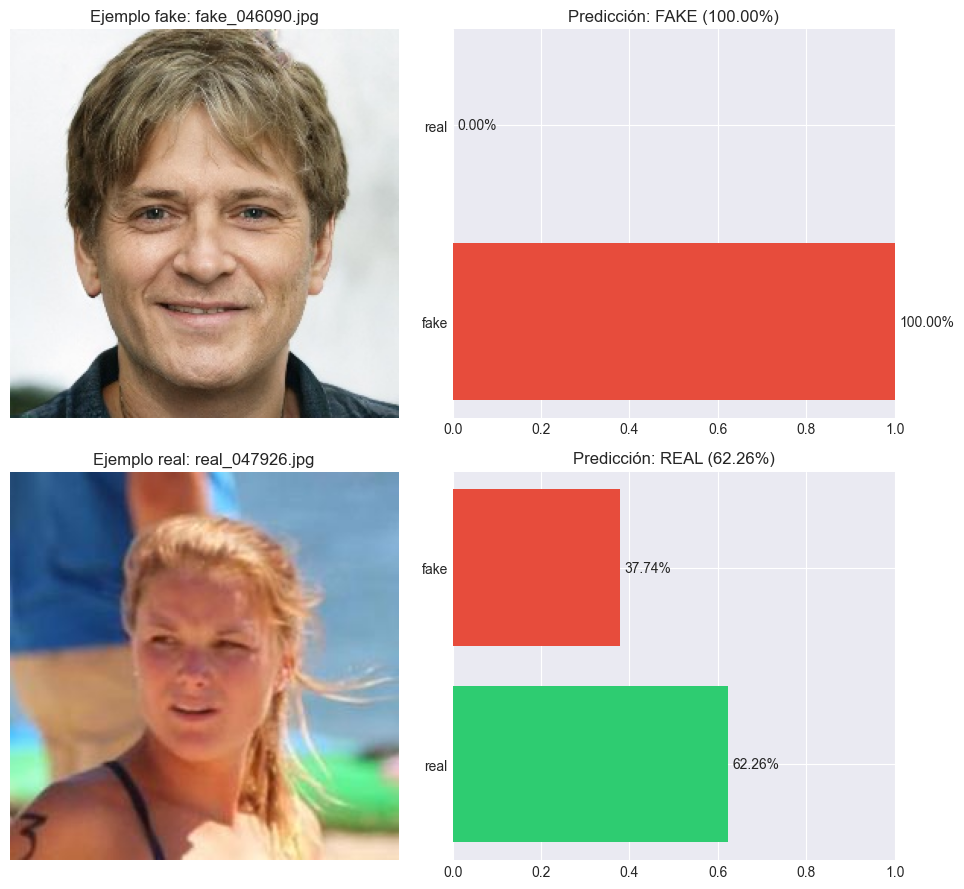

In [11]:
def sample_image(split: str, label: str) -> Path:
    candidates = sorted((DATASET_DIR / split / label).glob('*.jpg'))
    if not candidates:
        candidates = sorted((DATASET_DIR / split / label).glob('*.png'))
    if not candidates:
        raise FileNotFoundError(f'No se encontraron imágenes en {DATASET_DIR / split / label}')
    return random.choice(candidates)


example_fake = sample_image('test', 'fake')
example_real = sample_image('test', 'real')
example_paths = [('fake', example_fake), ('real', example_real)]

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for row_index, (expected_label, image_path) in enumerate(example_paths):
    prediction = classify_image(image_path, model_path=selected_model)
    image = Image.open(image_path).convert('RGB')

    axes[row_index, 0].imshow(image)
    axes[row_index, 0].set_title(f'Ejemplo {expected_label}: {image_path.name}')
    axes[row_index, 0].axis('off')

    labels = [label for label, _ in prediction['scores']]
    values = [score for _, score in prediction['scores']]
    colors = ['#e74c3c' if label == 'fake' else '#2ecc71' for label in labels]
    axes[row_index, 1].barh(labels, values, color=colors)
    axes[row_index, 1].set_xlim(0, 1)
    axes[row_index, 1].set_title(
        f'Predicción: {prediction["label"].upper()} ({prediction["confidence"]:.2%})'
    )
    for label, value in zip(labels, values):
        axes[row_index, 1].text(value + 0.01, label, f'{value:.2%}', va='center')

plt.tight_layout()
plt.show()

## 7. Demo de inferencia presentable

La función siguiente acepta una URL o una ruta local y presenta:
- la imagen original
- la etiqueta predicha
- la confianza principal
- las probabilidades por clase
- un resumen legible en texto

In [12]:
def resolve_input_image(image_input: str) -> Path:
    if image_input.startswith(('http://', 'https://')):
        parsed = urlparse(image_input)
        filename = Path(parsed.path).name or 'downloaded_image.jpg'
        target = DOWNLOAD_DIR / filename
        response = requests.get(image_input, timeout=60)
        response.raise_for_status()
        target.write_bytes(response.content)
        return target

    local_path = Path(image_input).expanduser().resolve()
    if local_path.exists():
        return local_path

    raise FileNotFoundError('Define una URL válida o una ruta local válida.')


def predict_and_display(image_input: str, model_path: Path) -> dict[str, object]:
    image_path = resolve_input_image(image_input)
    prediction = classify_image(image_path, model_path=model_path)
    scores = prediction['scores']
    labels = [label for label, _ in scores]
    values = [score for _, score in scores]
    image = Image.open(image_path).convert('RGB')

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.patch.set_facecolor('#161a2b')

    axes[0].imshow(image)
    axes[0].set_title(image_path.name, color='white')
    axes[0].axis('off')
    axes[0].set_facecolor('#161a2b')

    colors = ['#e74c3c' if label == 'fake' else '#2ecc71' for label in labels]
    axes[1].barh(labels, values, color=colors)
    axes[1].set_xlim(0, 1.05)
    axes[1].set_title(
        f'{prediction["label"].upper()}  |  confianza {prediction["confidence"]:.2%}',
        color='white'
    )
    axes[1].set_facecolor('#1d2746')
    axes[1].tick_params(colors='white')
    axes[1].set_xlabel('Probabilidad', color='white')
    for label, value in zip(labels, values):
        axes[1].text(value + 0.01, label, f'{value:.2%}', va='center', color='white')

    plt.tight_layout()
    plt.show()

    print('Resumen de inferencia:')
    print(f'  Imagen       = {image_path}')
    print(f'  Modelo       = {model_path}')
    print(f'  Predicción   = {prediction["label"]}')
    print(f'  Confianza    = {prediction["confidence"]:.2%}')
    for label, score in scores:
        print(f'  - {label}: {score:.2%}')

    return prediction


print('Función predict_and_display() lista.')

Función predict_and_display() lista.


## 8. Prueba una imagen local o una URL

Ejemplos de uso:
- una imagen del dataset
- una ruta local de Windows
- una URL directa a una imagen


image 1/1 D:\proyectos\Detector de ia\results\generated\downloads\silvio_rodriguez.jpg: 224x224 real 0.99, fake 0.01, 9.6ms
Speed: 2.8ms preprocess, 9.6ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)


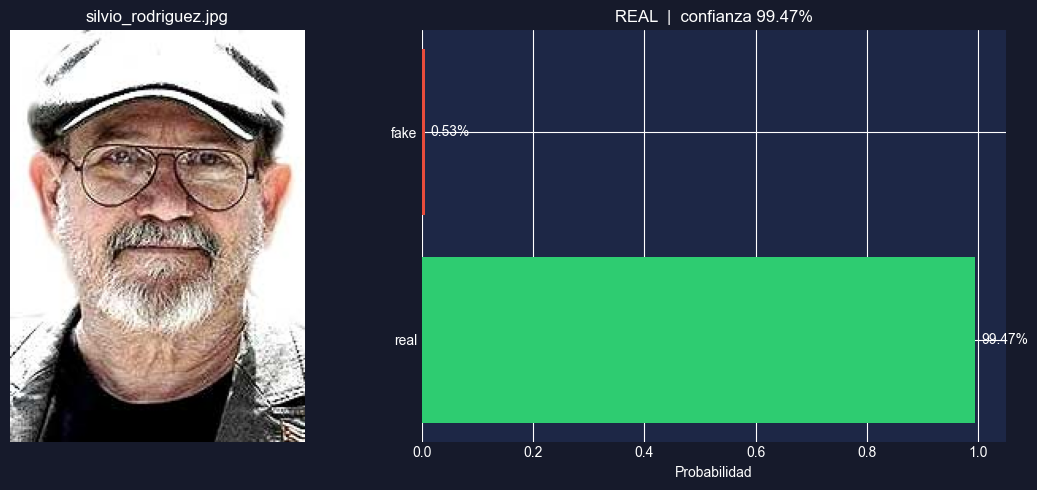

Resumen de inferencia:
  Imagen       = D:\proyectos\Detector de ia\results\generated\downloads\silvio_rodriguez.jpg
  Modelo       = D:\proyectos\Detector de ia\runs\classify\runs_yolo\deepfake_det_50606\weights\best.pt
  Predicción   = real
  Confianza    = 99.47%
  - real: 99.47%
  - fake: 0.53%


In [14]:
IMAGE_INPUT = str(DATASET_DIR / 'test' / 'fake' / 'fake_041594.jpg')
# IMAGE_INPUT = r'C:\ruta\a\tu\imagen.jpg'
IMAGE_INPUT = 'https://www.buscabiografias.com/img/people/silvio_rodriguez.jpg'

prediction = predict_and_display(IMAGE_INPUT, selected_model)

## 9. Siguientes usos

- Si hoy no vas a entrenar, trabaja con el modelo de referencia.
- Si luego quieres una corrida nueva, activa `CONFIRM_TRAINING = True`.
- Si esa nueva corrida resulta mejor, cambia `MODEL_PATH` o activa `USE_LATEST_MODEL = True`.
- Este cuaderno evita el balanceo experimental para conservar el comportamiento del cuaderno 02.